<a href="https://colab.research.google.com/github/Trieu1020/baitapANN/blob/main/ANN1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from keras.datasets import cifar100
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras.utils import to_categorical

path = '/content/drive/MyDrive/Money Data/data'

IMG_SIZE = 64
BATCH_SIZE = 8

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

Found 3204 images belonging to 4 classes.
Found 800 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Flatten(input_shape=(64, 64, 3)),  # chuyển ảnh thành vector 1D

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(train_data.num_classes, activation='softmax')  # đầu ra softmax cho phân loại
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)


Epoch 1/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.7412 - loss: 0.6525 - val_accuracy: 0.4688 - val_loss: 2.3147
Epoch 2/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 73s 89ms/step - accuracy: 0.9310 - loss: 0.1960 - val_accuracy: 0.9500 - val_loss: 0.0817
Epoch 3/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.9639 - loss: 0.0989 - val_accuracy: 0.8000 - val_loss: 0.5468
Epoch 4/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.9681 - loss: 0.0887 - val_accuracy: 0.9550 - val_loss: 0.1201
Epoch 5/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.9708 - loss: 0.0808 - val_accuracy: 0.9488 - val_loss: 0.1049
Epoch 6/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.9765 - loss: 0.0647 - val_accuracy: 0.8938 - val_loss: 0.4253
Epoch 7/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.9733 - loss: 0.0897 - val_accuracy: 0.8700 - val_loss: 0.4640
Epoch 8/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.9740 - loss: 0.0740 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Loại 2


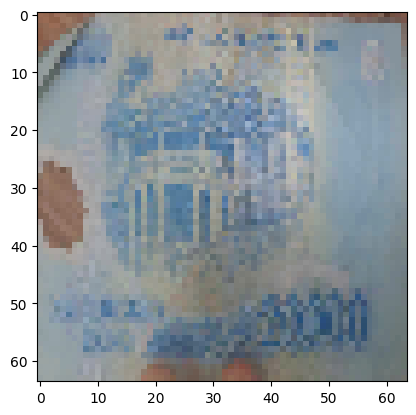

In [ ]:
from keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

url = '/content/z6495187245925_084850d54fbe7f5a22fe837ebf86649a.jpg'
img=load_img(url,target_size=(64,64))
plt.imshow(img)
img_array=img_to_array(img)/255
img_flatten=img_array.reshape(1,64,64,3)
prediction=model.predict(img_flatten)
print('Loại',np.argmax(prediction))